## Importation des packages

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
!pip install adjustText #installation du package adjustText
from adjustText import adjust_text

## Ouverture des fichiers


Procédure spécifique à Google Colab

In [ ]:
import subprocess
import sys
import gdown

FS_id = '1umPTpl949gnLYYW5UsDncpINrOKjYHmf'
url_FS= f'https://drive.google.com/uc?id={FS_id}'

gdown.download(url_FS, 'FS.csv', quiet=True)
FS = pd.read_csv('FS.csv', sep=';', decimal= ',')

Landings_id = '1k676aq26JDElOlqwU-fW-jaNnt7-tWCE'
url_Landings= f'https://drive.google.com/uc?id={Landings_id}'

gdown.download(url_Landings, 'Landings.csv', quiet=True)

Landings = pd.read_csv('Landings.csv', sep=';', decimal= ',')

/tmp/ipython-input-2443844212.py:9: DtypeWarning: Columns (18,20) have mixed types. Specify dtype option on import or set low_memory=False.
  FS = pd.read_csv('FS.csv', sep=';', decimal= ',')
/tmp/ipython-input-2443844212.py:16: DtypeWarning: Columns (8,10) have mixed types. Specify dtype option on import or set low_memory=False.
  Landings = pd.read_csv('Landings.csv', sep=';', decimal= ',')


In [ ]:
FS.head()

,upload_date,country_name,country_code,year,supra_reg,fishing_tech,vessel_length,geo_indicator,cluster_name,fs_name,...,variable_name,variable_code,value,unit,fromtable,framework,template_name,gear,fishery,activity
0,01/10/2018,Belgium,BEL,2008,AREA27,TBB,VL2440,NGI,NaN,BEL NAO TBB2440 NGI,...,Gross value of landings,totlandginc,54698472.45,euro,map_fs,map,map_fs,NaN,NaN,NaN
1,01/10/2018,Belgium,BEL,2008,AREA27,DTS,VL1012,NGI,AREA27 DTS VL2440,BEL NAO DTS2440 NGI *,...,Gross value of landings,totlandginc,NaN,euro,map_fs,map,map_fs,NaN,NaN,NaN
2,01/10/2018,Belgium,BEL,2008,AREA27,DTS,VL1824,NGI,AREA27 DTS VL2440,BEL NAO DTS2440 NGI *,...,Gross value of landings,totlandginc,NaN,euro,map_fs,map,map_fs,NaN,NaN,NaN
3,01/10/2018,Belgium,BEL,2008,AREA27,DTS,VL2440,NGI,AREA27 DTS VL2440,BEL NAO DTS2440 NGI *,...,Gross value of landings,totlandginc,4529620.35,euro,map_fs,map,map_fs,NaN,NaN,NaN
4,01/10/2018,Belgium,BEL,2008,AREA27,INACTIVE,VL1824,NGI,AREA27 INACTIVE VL2440,BEL NAO INA2440 NGI *,...,Gross value of landings,totlandginc,NaN,euro,map_fs,map,map_fs,NaN,NaN,NaN


In [ ]:
FS.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 385859 entries, 0 to 385858
Data columns (total 21 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   upload_date     385859 non-null  object 
 1   country_name    385859 non-null  object 
 2   country_code    385859 non-null  object 
 3   year            385859 non-null  int64  
 4   supra_reg       385859 non-null  object 
 5   fishing_tech    385859 non-null  object 
 6   vessel_length   385859 non-null  object 
 7   geo_indicator   343317 non-null  object 
 8   cluster_name    201069 non-null  object 
 9   fs_name         385859 non-null  object 
 10  variable_group  385859 non-null  object 
 11  variable_name   385859 non-null  object 
 12  variable_code   385859 non-null  object 
 13  value           230509 non-null  float64
 14  unit            385859 non-null  object 
 15  fromtable       385859 non-null  object 
 16  framework       385859 non-null  object 
 17  template_n

In [ ]:
Landings.head()

,upload_date,country_name,country_code,year,supra_reg,fishing_tech,vessel_length,geo_indicator,gear,fishery,...,variable_name,variable_code,value,unit,species_name,species_code,sub_reg,fromtable,framework,template_name
0,01/10/2018,Belgium,BEL,2008,AREA27,TBB,VL1824,NGI,NaN,NaN,...,Value of landings,totvallandg,139.59,euro,Thornback ray,RJC,27.4.b,map_fsfao,map,map_fsfao
1,01/10/2018,Belgium,BEL,2008,AREA27,TBB,VL2440,NGI,NaN,NaN,...,Value of landings,totvallandg,2698836.79,euro,Common sole,SOL,27.7.f,map_fsfao,map,map_fsfao
2,01/10/2018,Belgium,BEL,2008,AREA27,DTS,VL2440,NGI,NaN,NaN,...,Live weight of landings,totwghtlandg,44652.69,kg,Common sole,SOL,27.7.d,map_fsfao,map,map_fsfao
3,01/10/2018,Belgium,BEL,2008,AREA27,PMP,VL1824,NGI,NaN,NaN,...,Value of landings,totvallandg,298.61,euro,Lemon sole,LEM,27.4.c,map_fsfao,map,map_fsfao
4,01/10/2018,Belgium,BEL,2008,AREA27,TBB,VL2440,NGI,NaN,NaN,...,Value of landings,totvallandg,11144.66,euro,Atlantic cod,COD,27.7.e,map_fsfao,map,map_fsfao


In [ ]:
Landings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1694910 entries, 0 to 1694909
Data columns (total 24 columns):
 #   Column          Dtype  
---  ------          -----  
 0   upload_date     object 
 1   country_name    object 
 2   country_code    object 
 3   year            int64  
 4   supra_reg       object 
 5   fishing_tech    object 
 6   vessel_length   object 
 7   geo_indicator   object 
 8   gear            object 
 9   fishery         float64
 10  activity        object 
 11  cluster_name    object 
 12  fs_name         object 
 13  variable_group  object 
 14  variable_name   object 
 15  variable_code   object 
 16  value           float64
 17  unit            object 
 18  species_name    object 
 19  species_code    object 
 20  sub_reg         object 
 21  fromtable       object 
 22  framework       object 
 23  template_name   object 
dtypes: float64(2), int64(1), object(21)
memory usage: 310.3+ MB


Le dataframe landings possède 3 colonnes supplémentaires : 'species_name', 'species_code' et 'sub_reg'.    
Après diverses explorations, et compte tenu de la taille du fichier landings, ces deux dataframes ne seront pas concaténés.   
Pour plus de lisibilité, les colonnes des deux dataframes sont ordonnées de la même façon.

In [ ]:
FS.columns

Index(['upload_date', 'country_name', 'country_code', 'year', 'supra_reg',
       'fishing_tech', 'vessel_length', 'geo_indicator', 'cluster_name',
       'fs_name', 'variable_group', 'variable_name', 'variable_code', 'value',
       'unit', 'fromtable', 'framework', 'template_name', 'gear', 'fishery',
       'activity'],
      dtype='object')

In [ ]:
Landings.columns

Index(['upload_date', 'country_name', 'country_code', 'year', 'supra_reg',
       'fishing_tech', 'vessel_length', 'geo_indicator', 'gear', 'fishery',
       'activity', 'cluster_name', 'fs_name', 'variable_group',
       'variable_name', 'variable_code', 'value', 'unit', 'species_name',
       'species_code', 'sub_reg', 'fromtable', 'framework', 'template_name'],
      dtype='object')

In [ ]:
FS = FS[['upload_date', 'country_name', 'country_code', 'year', 'supra_reg',
       'fishing_tech', 'vessel_length', 'geo_indicator', 'gear', 'fishery', 'activity','cluster_name',
       'fs_name', 'variable_group', 'variable_name', 'variable_code', 'value',
       'unit', 'fromtable', 'framework', 'template_name']]

In [ ]:
Landings = Landings[['upload_date', 'country_name', 'country_code', 'year', 'supra_reg',
       'fishing_tech', 'vessel_length', 'geo_indicator', 'gear', 'fishery',
       'activity', 'cluster_name', 'fs_name', 'variable_group',
       'variable_name', 'variable_code', 'value', 'unit', 'fromtable', 'framework', 'template_name','species_name',
       'species_code', 'sub_reg']]

In [ ]:
FS.shape

(385859, 21)

In [ ]:
Landings.shape

(1694910, 24)

In [ ]:
colonnes_nbna_landings = Landings.isnull().sum()
colonnes_nbna_landings

,0
upload_date,0
country_name,0
country_code,0
year,0
supra_reg,0
fishing_tech,0
vessel_length,0
geo_indicator,107326
gear,1489162
fishery,1694910


In [ ]:
plt.figure(figsize=(14, 6))
ax = sns.barplot(x=Landings.isna().sum().index, y=Landings.isna().sum().values)

# Ajouter les étiquettes de données en haut des barres
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

# Titres des axes
plt.xlabel('Colonnes du jeu de données Landings')
plt.ylabel('Nombre de valeurs manquantes')
plt.title('Distribution des valeurs manquantes dans le jeu de données Landings')

# Rotation des labels
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show();

NameError: name 'plt' is not defined

In [ ]:
colonnes_nbna_FS = FS.isnull().sum()
colonnes_nbna_FS

,0
upload_date,0
country_name,0
country_code,0
year,0
supra_reg,0
fishing_tech,0
vessel_length,0
geo_indicator,42542
gear,359327
fishery,385859


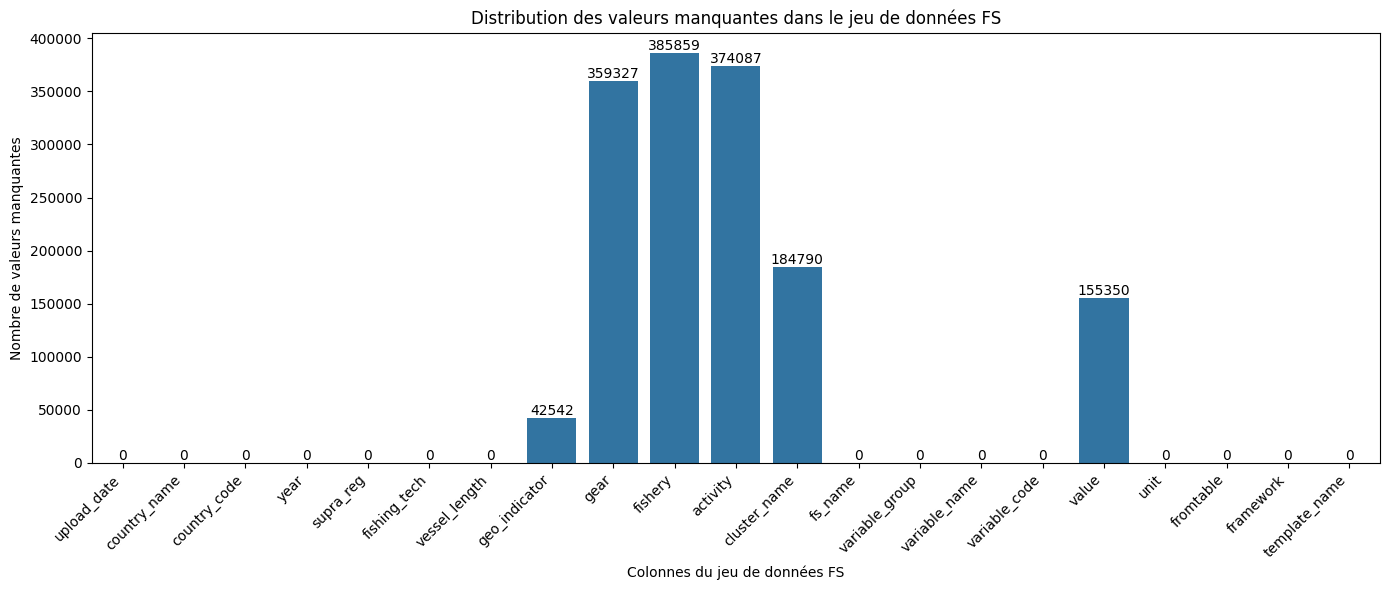

In [ ]:
plt.figure(figsize=(14, 6))
ax = sns.barplot(x=FS.isna().sum().index, y=FS.isna().sum().values)

# Ajouter les étiquettes de données en haut des barres
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

# Titres des axes
plt.xlabel('Colonnes du jeu de données FS')
plt.ylabel('Nombre de valeurs manquantes')
plt.title('Distribution des valeurs manquantes dans le jeu de données FS')

# Rotation des labels
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show();

In [ ]:
FS['variable_name'].value_counts()

,count
variable_name,
Gross value of landings,11499
Income from leasing out quota,11499
Operating subsidies,11499
Other income,11499
Personnel costs,11499
Value of unpaid labour,11499
Energy costs,11499
Repair & maintenance costs,11499
Other variable costs,11499


In [ ]:
Landings['variable_name'].value_counts()

,count
variable_name,
Value of landings,847455
Live weight of landings,847455


## Filtrage (colonnes d'intéret, unités, 2023)

Pour analyser et visualiser les données en fonction de nos variables, il faut pivoter la variable "variable_name".     
Avant cela, la variable 'variable_name_unit' est créée, elle permet de s'affranchir de la colonne 'unit'.    
Les colonnes d'intérêts sont conservées, et le dataframe est filtré pour éliminer les données incomplètes de 2023.

In [ ]:
Landings['variable_name_unit'] =  Landings['variable_name'] + ' (' + Landings['unit'] + ')'
FS['variable_name_unit'] =  FS['variable_name'] + ' (' + FS['unit'] + ')'

Landings_long = Landings.loc[(Landings['year'] < 2023), ['year','country_name','supra_reg','fishing_tech', 'vessel_length','fs_name', 'variable_name_unit', 'value','species_name','species_code','sub_reg']]

FS_long = FS.loc[(FS['year'] < 2023), ['year','country_name','supra_reg','fishing_tech', 'vessel_length','fs_name', 'variable_name_unit', 'value']]
FS_long = FS_long.loc[~FS_long['variable_name_unit'].isin(['Mean age of vessels (year)', 'Mean LOA of vessels (metre)','Maximum days at sea (day)']),]


display(Landings_long.head())
display(FS_long.head())

#Landings_long.to_csv('Landings_long.csv', index= False, sep=';', decimal=',')
#FS_long.to_csv('FS_long.csv', index= False, sep=';', decimal=',')

,year,country_name,supra_reg,fishing_tech,vessel_length,fs_name,variable_name_unit,value,species_name,species_code,sub_reg
0,2008,Belgium,AREA27,TBB,VL1824,BEL NAO TBB1824 NGI *,Value of landings (euro),139.59,Thornback ray,RJC,27.4.b
1,2008,Belgium,AREA27,TBB,VL2440,BEL NAO TBB2440 NGI,Value of landings (euro),2698836.79,Common sole,SOL,27.7.f
2,2008,Belgium,AREA27,DTS,VL2440,BEL NAO DTS2440 NGI *,Live weight of landings (kg),44652.69,Common sole,SOL,27.7.d
3,2008,Belgium,AREA27,PMP,VL1824,BEL NAO PMP1824 NGI *,Value of landings (euro),298.61,Lemon sole,LEM,27.4.c
4,2008,Belgium,AREA27,TBB,VL2440,BEL NAO TBB2440 NGI,Value of landings (euro),11144.66,Atlantic cod,COD,27.7.e


,year,country_name,supra_reg,fishing_tech,vessel_length,fs_name,variable_name_unit,value
0,2008,Belgium,AREA27,TBB,VL2440,BEL NAO TBB2440 NGI,Gross value of landings (euro),54698472.45
1,2008,Belgium,AREA27,DTS,VL1012,BEL NAO DTS2440 NGI *,Gross value of landings (euro),NaN
2,2008,Belgium,AREA27,DTS,VL1824,BEL NAO DTS2440 NGI *,Gross value of landings (euro),NaN
3,2008,Belgium,AREA27,DTS,VL2440,BEL NAO DTS2440 NGI *,Gross value of landings (euro),4529620.35
4,2008,Belgium,AREA27,INACTIVE,VL1824,BEL NAO INA2440 NGI *,Gross value of landings (euro),NaN


## Formatage du dataframe

On pivote toutes les données, avant de leur affecter une classe cat_vessel et cat_fleet. On a encore des NA dans les données économiques uniquement : c'est normal car on a nos lignes sans données et les lignes INACTIVE.

### Landings

In [ ]:
Landings_wide = Landings_long.pivot_table(
    index=[
        "year",
        "country_name",
        "supra_reg",
        'sub_reg',
        'fishing_tech',
        'vessel_length',
        'fs_name',
        "species_code",
        "species_name"
    ],
    columns="variable_name_unit",
    values="value",
    aggfunc="sum"
).reset_index()

display(Landings_wide.head())
display(Landings_wide.shape)

#Vérif des NA
Landings_wide.isna().sum()
#display(Landings_wide['vessel_category'].value_counts())
#display(Landings_wide['fleet_category'].value_counts())

variable_name_unit,year,country_name,supra_reg,sub_reg,fishing_tech,vessel_length,fs_name,species_code,species_name,Live weight of landings (kg),Value of landings (euro)
0,2008,Belgium,AREA27,27.4.a,TBB,VL2440,BEL NAO TBB2440 NGI,ANF,Anglerfishes nei,23806.97,73586.11
1,2008,Belgium,AREA27,27.4.a,TBB,VL2440,BEL NAO TBB2440 NGI,BLL,Brill,488.80,4178.37
2,2008,Belgium,AREA27,27.4.a,TBB,VL2440,BEL NAO TBB2440 NGI,CAA,Atlantic wolffish,23652.16,57244.79
3,2008,Belgium,AREA27,27.4.a,TBB,VL2440,BEL NAO TBB2440 NGI,COD,Atlantic cod,40948.02,126447.49
4,2008,Belgium,AREA27,27.4.a,TBB,VL2440,BEL NAO TBB2440 NGI,COE,European conger,0.24,0.51


(837275, 11)

,0
variable_name_unit,
year,0
country_name,0
supra_reg,0
sub_reg,0
fishing_tech,0
vessel_length,0
fs_name,0
species_code,0
species_name,0


### FS

In [ ]:
FS_wide = FS_long.pivot_table(
    index=[
        "year",
        "country_name",
        "supra_reg",
        'fishing_tech',
        'vessel_length',
        'fs_name'
    ],
    columns="variable_name_unit",
    values="value",
    aggfunc="sum"
).reset_index()

display(FS_wide.shape)
display(FS_wide.head())
#Vérif des NA
FS_wide.isna().sum()

(10734, 39)

variable_name_unit,year,country_name,supra_reg,fishing_tech,vessel_length,fs_name,Consumption of fixed capital (euro),Days at sea (day),Energy consumption (litre),Energy costs (euro),...,Total assets (euro),Total hours worked per year (engaged crew) (hour),Total vessel power (kW),Total vessel tonnage (GT),Unpaid labour (number),Value of physical capital (euro),Value of quota and other fishing rights (euro),Value of unpaid labour (euro),kW days at sea (kWday),kW fishing days (kWday)
0,2008,Belgium,AREA27,DTS,VL1012,BEL NAO DTS2440 NGI *,0.0,0.0,0.0,0.0,...,NaN,NaN,221.0,21.0,NaN,0.0,0.0,0.0,NaN,0.0
1,2008,Belgium,AREA27,DTS,VL1824,BEL NAO DTS2440 NGI *,0.0,0.0,0.0,0.0,...,NaN,NaN,221.0,104.0,NaN,0.0,0.0,0.0,NaN,0.0
2,2008,Belgium,AREA27,DTS,VL2440,BEL NAO DTS2440 NGI *,660950.0,1224.0,4357692.0,1665120.0,...,NaN,NaN,3002.0,1014.0,NaN,3427550.0,0.0,365114.0,NaN,767422.0
3,2008,Belgium,AREA27,INACTIVE,VL1824,BEL NAO INA2440 NGI *,0.0,0.0,0.0,0.0,...,NaN,NaN,442.0,152.0,NaN,0.0,0.0,0.0,NaN,0.0
4,2008,Belgium,AREA27,INACTIVE,VL2440,BEL NAO INA2440 NGI *,0.0,0.0,0.0,0.0,...,NaN,NaN,929.0,246.0,NaN,0.0,0.0,0.0,NaN,0.0


,0
variable_name_unit,
year,0
country_name,0
supra_reg,0
fishing_tech,0
vessel_length,0
fs_name,0
Consumption of fixed capital (euro),0
Days at sea (day),0
Energy consumption (litre),0


In [ ]:
NA_all_FS = pd.DataFrame({
    "nb_NA": FS_wide.isna().sum(),
    "pct_NA": round(FS_wide.isna().mean() * 100, 2)
}).reset_index().rename(columns={"index": "column"})

display(NA_all_FS)

,variable_name_unit,nb_NA,pct_NA
0,year,0,0.0
1,country_name,0,0.0
2,supra_reg,0,0.0
3,fishing_tech,0,0.0
4,vessel_length,0,0.0
5,fs_name,0,0.0
6,Consumption of fixed capital (euro),0,0.0
7,Days at sea (day),0,0.0
8,Energy consumption (litre),0,0.0
9,Energy costs (euro),0,0.0


## Catégorisation des techniques de pêche, taille des navires et espèces débarquées

Vérification des différentes catégories de techniques de pêche et de taille de navires dans le fichier.

In [ ]:
FS_wide['fishing_tech'].value_counts()

,count
fishing_tech,
INACTIVE,1881
HOK,1299
DTS,1271
DFN,941
PS,856
FPO,738
TM,729
PGP,680
PMP,665


In [ ]:
nb_lignes_FS = (FS_wide["fishing_tech"] == "INACTIVE").sum()
print(nb_lignes_FS)

FS_wide.shape

1881


(10734, 39)

In [ ]:
FS_wide['vessel_length'].value_counts()

,count
vessel_length,
VL1218,2153
VL1824,1636
VL0010,1535
VL2440,1498
VL1012,1384
VL0612,972
VL0006,701
VL40XX,605
VL0812,150


In [ ]:
Landings_wide['fishing_tech'].value_counts()

,count
fishing_tech,
DTS,253351
DFN,116471
HOK,111071
PGP,75165
PMP,65610
PS,45846
FPO,41868
TM,34868
TBB,29382


In [ ]:
Landings_wide['vessel_length'].value_counts()

,count
vessel_length,
VL1218,176599
VL2440,146615
VL1824,138612
VL0010,110225
VL1012,104500
VL0612,82979
VL40XX,36968
VL0006,33829
VL0812,3616


Définitions des 3 fonctions pour catégoriser les techniques de pêche, la taille des navires et les espèces.

```
Français,Anglais
"Dor - Filets, lignes, casiers","PG - Passive gears (nets, lines, traps)"
Dra - Dragues et polyvalents,Dre - Dredgers and polyvalent
ChaD - Chaluts et sennes démersaux,traD - Demersal trawlers and seiners
ChaP - Chaluts et sennes pélagiques,traP - Pelagic trawlers and seiners
```

```
Français,Anglais
Côtier,Inshore
Hauturier,Offshore
Industriel,Industrial
```

In [ ]:
#Catégorie anglais
def cat_fleet(x):
    if x =='DFN' or x=='FPO' or x=='HOK' or x=='MGO' or x== 'PGO' or x== 'PGP' or x=='PG':
        return 'PG'
    elif x== 'DRB' or x== 'MGP' or x=='PMP':
        return 'Dre'
    elif x== 'DTS' or x== 'TBB':
        return 'TraD'
    elif x== 'PS' or x== 'TM':
        return 'TraP'
    else:
        return 'INACTIVE'

def cat_vessel(x):
    #if x =='VL0006' or x=='VL0010' or x=='VL0612' or x=='VL1012' or x=='VL0008' or x=='VL0812':
        #return 'Cotier'
    if x== 'VL1218' or x== 'VL1824':
        return 'Offshore'
    elif x== 'VL2440' or x== 'VL40XX':
        return 'Industrial'
    else:
        return 'Inshore'

def cat_specie(x):
    if x =='Carragheen (Irish) moss' or x=='Giant gelidium' or x=='North Atlantic rockweed' or x=='North European kelp' or x=='Sea lettuce' or x=='Sea thong' or x=='Seaweeds nei' or x=='Tangle':
        return 'Algae'
    else:
        return 'Animal'

Par rapport à l'étude du programme transipêche, les bâteaux des catégories 'VL0008' et 'VL0812' sont ajoutés à la catégorie 'Inshore'.   
Pour les flottilles, la technique 'PG' (passive gear) correspond à la catégorie 'Dor'. Les autres sont inactifs.

In [ ]:
Landings_wide['fleet_category'] = Landings_wide['fishing_tech'].apply(cat_fleet)
FS_wide['fleet_category'] = FS_wide['fishing_tech'].apply(cat_fleet)
display(Landings_wide['fleet_category'].value_counts())
display(FS_wide['fleet_category'].value_counts())

,count
fleet_category,
PG,371191
TraD,282733
Dre,102637
TraP,80714


,count
fleet_category,
PG,4269
INACTIVE,1881
TraD,1710
TraP,1585
Dre,1289


In [ ]:
Landings_wide['vessel_category'] = Landings_wide['vessel_length'].apply(cat_vessel)
FS_wide['vessel_category'] = FS_wide['vessel_length'].apply(cat_vessel)
display(Landings_wide['vessel_category'].value_counts())
display(FS_wide['vessel_category'].value_counts())

,count
vessel_category,
Inshore,338481
Offshore,315211
Industrial,183583


,count
vessel_category,
Inshore,4842
Offshore,3789
Industrial,2103


In [ ]:
Landings_wide['specie_category'] = Landings_wide['species_name'].apply(cat_specie)
Landings_wide['specie_category'].value_counts()

,count
specie_category,
Animal,836757
Algae,518


## Gestion des données manquantes


Nous avons maintenant 2 fichiers WIDE dont le fichier FS_wide qui contient bcp de NA. Ces NA sont liés aux flottes INACTIVES et aux agrégations.

- On commence par enlever les lignes INACTIVE
- On remplace ensuite les NA par des 0

In [ ]:
display(Landings_wide.isna().sum())

,0
variable_name_unit,
year,0
country_name,0
supra_reg,0
sub_reg,0
fishing_tech,0
vessel_length,0
fs_name,0
species_code,0
species_name,0


Landings n'a pas de NA.

In [ ]:

display(FS_wide.isna().sum())

,0
variable_name_unit,
year,0
country_name,0
supra_reg,0
fishing_tech,0
vessel_length,0
fs_name,0
Consumption of fixed capital (euro),0
Days at sea (day),0
Energy consumption (litre),0


In [ ]:
#Suppression des lignes où cat_fleet = INACTIVE
FS_wide=FS_wide.loc[FS_wide["fleet_category"] != "INACTIVE"]
display(FS_wide.head())

Landings_wide = Landings_wide.loc[(Landings_wide["fleet_category"] != "INACTIVE") &(Landings_wide["specie_category"] == "Animal")]
display(Landings_wide.head())

variable_name_unit,year,country_name,supra_reg,fishing_tech,vessel_length,fs_name,Consumption of fixed capital (euro),Days at sea (day),Energy consumption (litre),Energy costs (euro),...,Total vessel power (kW),Total vessel tonnage (GT),Unpaid labour (number),Value of physical capital (euro),Value of quota and other fishing rights (euro),Value of unpaid labour (euro),kW days at sea (kWday),kW fishing days (kWday),fleet_category,vessel_category
0,2008,Belgium,AREA27,DTS,VL1012,BEL NAO DTS2440 NGI *,0.0,0.0,0.0,0.0,...,221.0,21.0,NaN,0.0,0.0,0.0,NaN,0.0,TraD,Inshore
1,2008,Belgium,AREA27,DTS,VL1824,BEL NAO DTS2440 NGI *,0.0,0.0,0.0,0.0,...,221.0,104.0,NaN,0.0,0.0,0.0,NaN,0.0,TraD,Offshore
2,2008,Belgium,AREA27,DTS,VL2440,BEL NAO DTS2440 NGI *,660950.0,1224.0,4357692.0,1665120.0,...,3002.0,1014.0,NaN,3427550.0,0.0,365114.0,NaN,767422.0,TraD,Industrial
5,2008,Belgium,AREA27,PMP,VL1218,BEL NAO PMP1824 NGI *,0.0,0.0,0.0,0.0,...,853.0,30.0,NaN,0.0,0.0,0.0,NaN,0.0,Dre,Offshore
6,2008,Belgium,AREA27,PMP,VL1824,BEL NAO PMP1824 NGI *,116709.0,480.0,45723.0,31899.0,...,450.0,133.0,NaN,1650000.0,0.0,0.0,NaN,179861.0,Dre,Offshore


variable_name_unit,year,country_name,supra_reg,sub_reg,fishing_tech,vessel_length,fs_name,species_code,species_name,Live weight of landings (kg),Value of landings (euro),fleet_category,vessel_category,specie_category
0,2008,Belgium,AREA27,27.4.a,TBB,VL2440,BEL NAO TBB2440 NGI,ANF,Anglerfishes nei,23806.97,73586.11,TraD,Industrial,Animal
1,2008,Belgium,AREA27,27.4.a,TBB,VL2440,BEL NAO TBB2440 NGI,BLL,Brill,488.80,4178.37,TraD,Industrial,Animal
2,2008,Belgium,AREA27,27.4.a,TBB,VL2440,BEL NAO TBB2440 NGI,CAA,Atlantic wolffish,23652.16,57244.79,TraD,Industrial,Animal
3,2008,Belgium,AREA27,27.4.a,TBB,VL2440,BEL NAO TBB2440 NGI,COD,Atlantic cod,40948.02,126447.49,TraD,Industrial,Animal
4,2008,Belgium,AREA27,27.4.a,TBB,VL2440,BEL NAO TBB2440 NGI,COE,European conger,0.24,0.51,TraD,Industrial,Animal


Visualisation des données manquantes

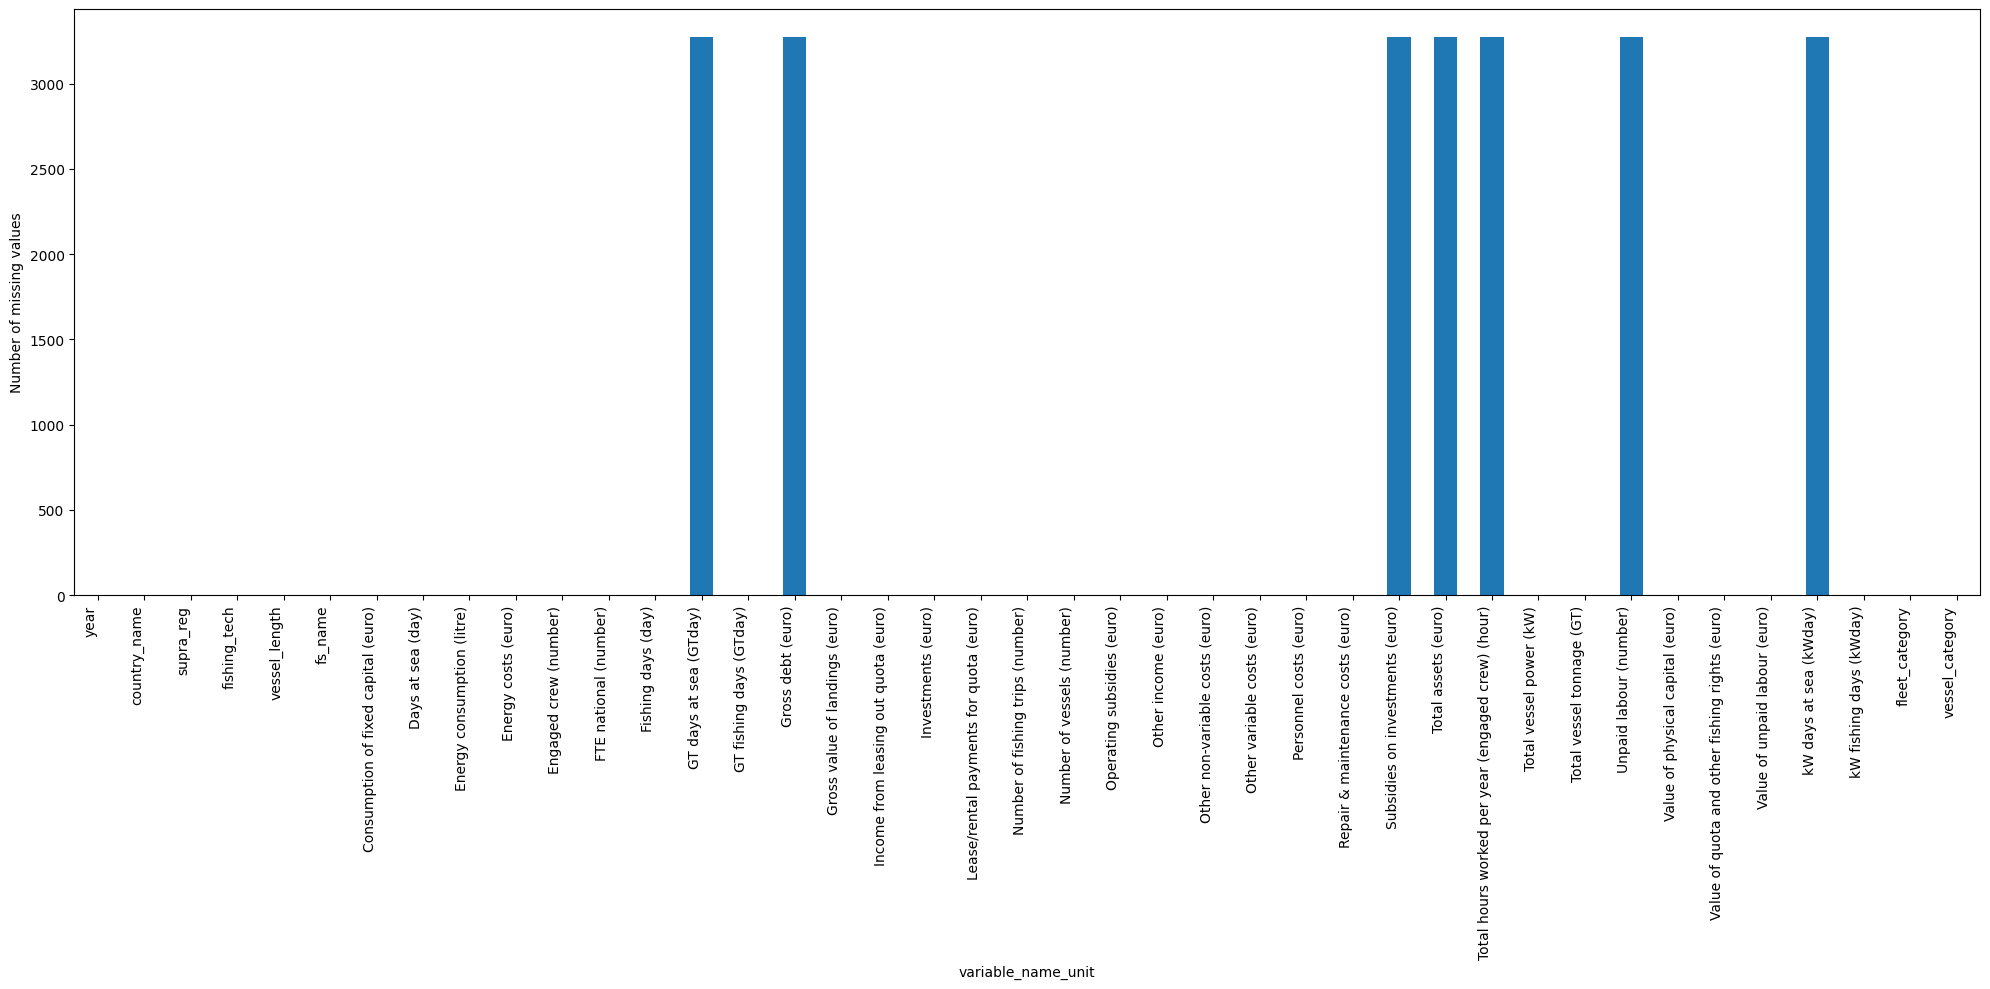

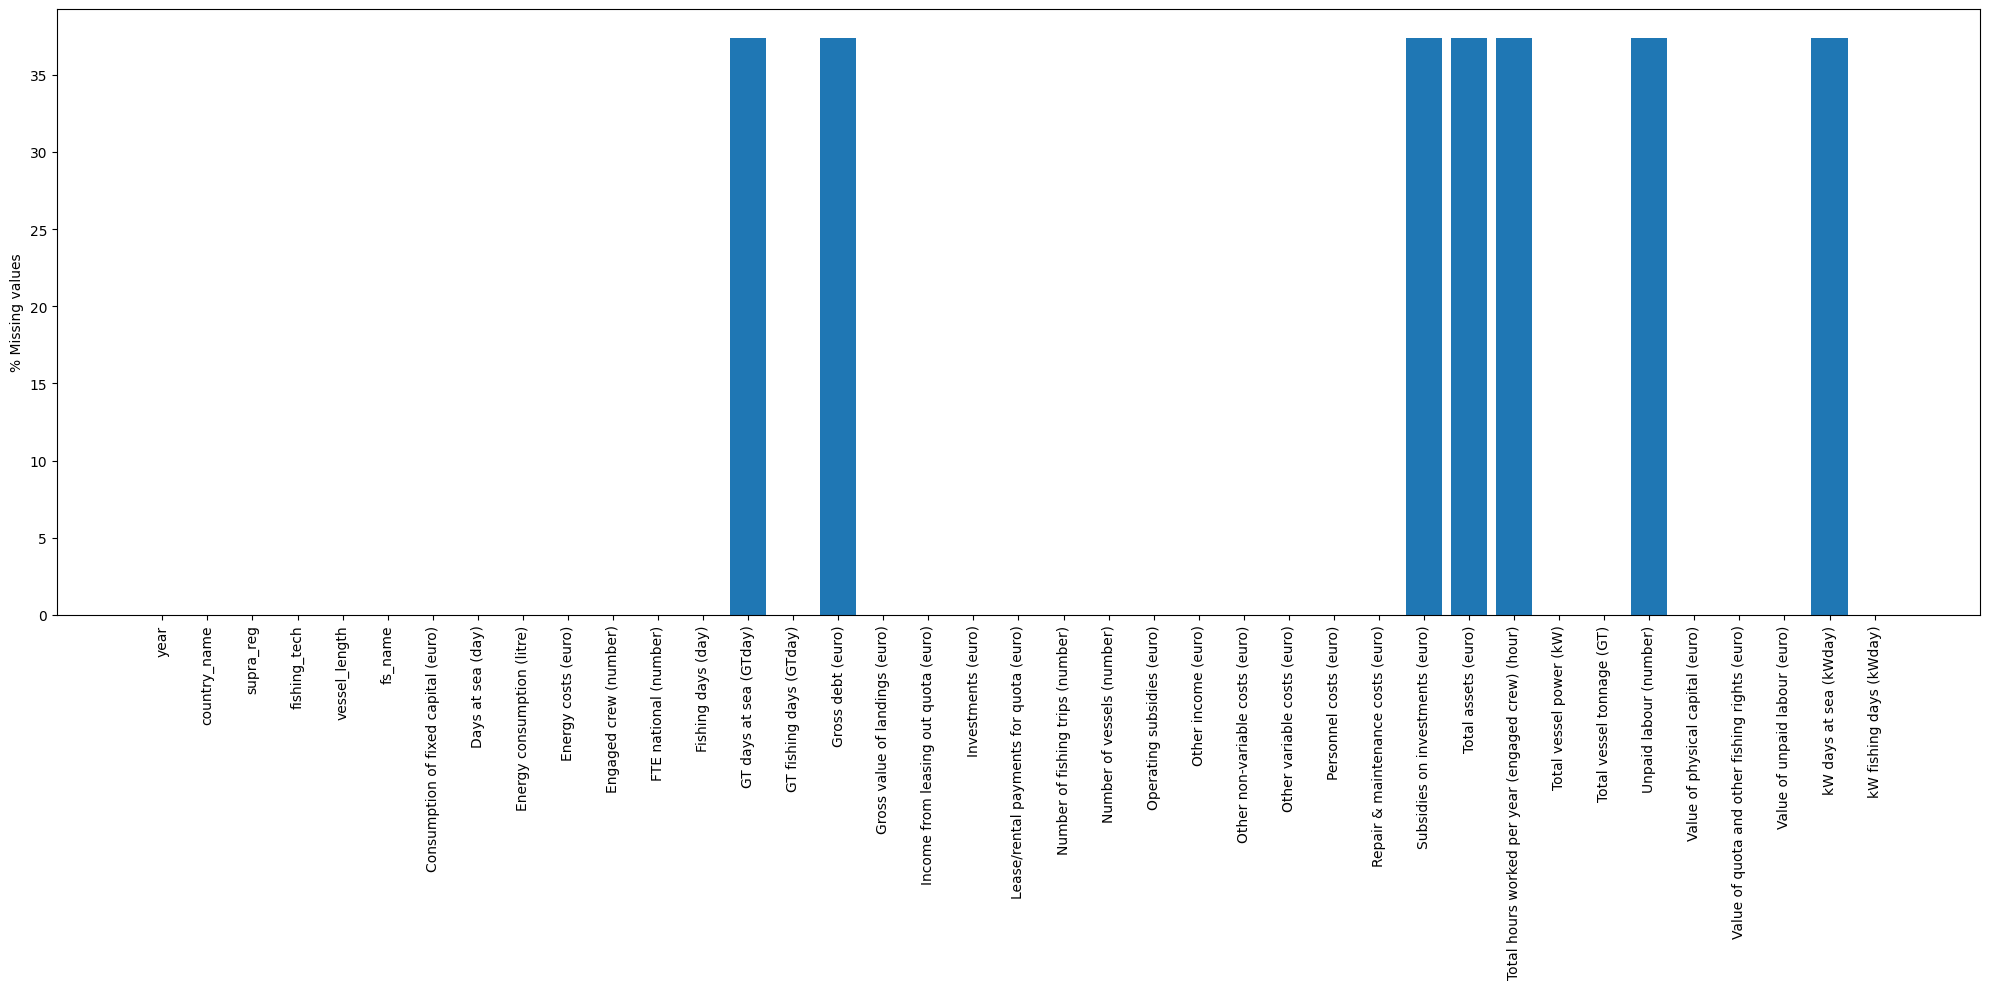

In [ ]:
missing_counts = FS_wide.isna().sum()

plt.figure(figsize=(20, 10))
missing_counts.plot(kind='bar')
plt.ylabel("Number of missing values")
plt.xticks(rotation=90, ha="right")
plt.tight_layout()
plt.show();

print("\n")

plt.figure(figsize=(20, 10))
plt.bar(NA_all_FS["variable_name_unit"], NA_all_FS["pct_NA"])
plt.xticks(rotation=90)
plt.ylabel("% Missing values")
plt.tight_layout()
plt.show();


Nous remplaçons par des 0 les données manquantes dans FS.

In [ ]:
FS_wide = FS_wide.fillna(0)

In [ ]:
FS_wide.isna().sum()

,0
variable_name_unit,
year,0
country_name,0
supra_reg,0
fishing_tech,0
vessel_length,0
fs_name,0
Consumption of fixed capital (euro),0
Days at sea (day),0
Energy consumption (litre),0


## Visualisations

### FS

#### Corrélation entre les variables économiques

In [ ]:
var_num = FS_wide.select_dtypes(include =['int','float'])
var_num.head()


variable_name_unit,year,Consumption of fixed capital (euro),Days at sea (day),Energy consumption (litre),Energy costs (euro),Engaged crew (number),FTE national (number),Fishing days (day),GT days at sea (GTday),GT fishing days (GTday),...,Total assets (euro),Total hours worked per year (engaged crew) (hour),Total vessel power (kW),Total vessel tonnage (GT),Unpaid labour (number),Value of physical capital (euro),Value of quota and other fishing rights (euro),Value of unpaid labour (euro),kW days at sea (kWday),kW fishing days (kWday)
0,2008,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,...,0.0,0.0,221.0,21.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2008,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,...,0.0,0.0,221.0,104.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2008,660950.0,1224.0,4357692.0,1665120.0,27.0,22.06,1200.0,0.0,257917.0,...,0.0,0.0,3002.0,1014.0,0.0,3427550.0,0.0,365114.0,0.0,767422.0
5,2008,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,...,0.0,0.0,853.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0
6,2008,116709.0,480.0,45723.0,31899.0,6.0,7.62,417.0,0.0,21641.0,...,0.0,0.0,450.0,133.0,0.0,1650000.0,0.0,0.0,0.0,179861.0


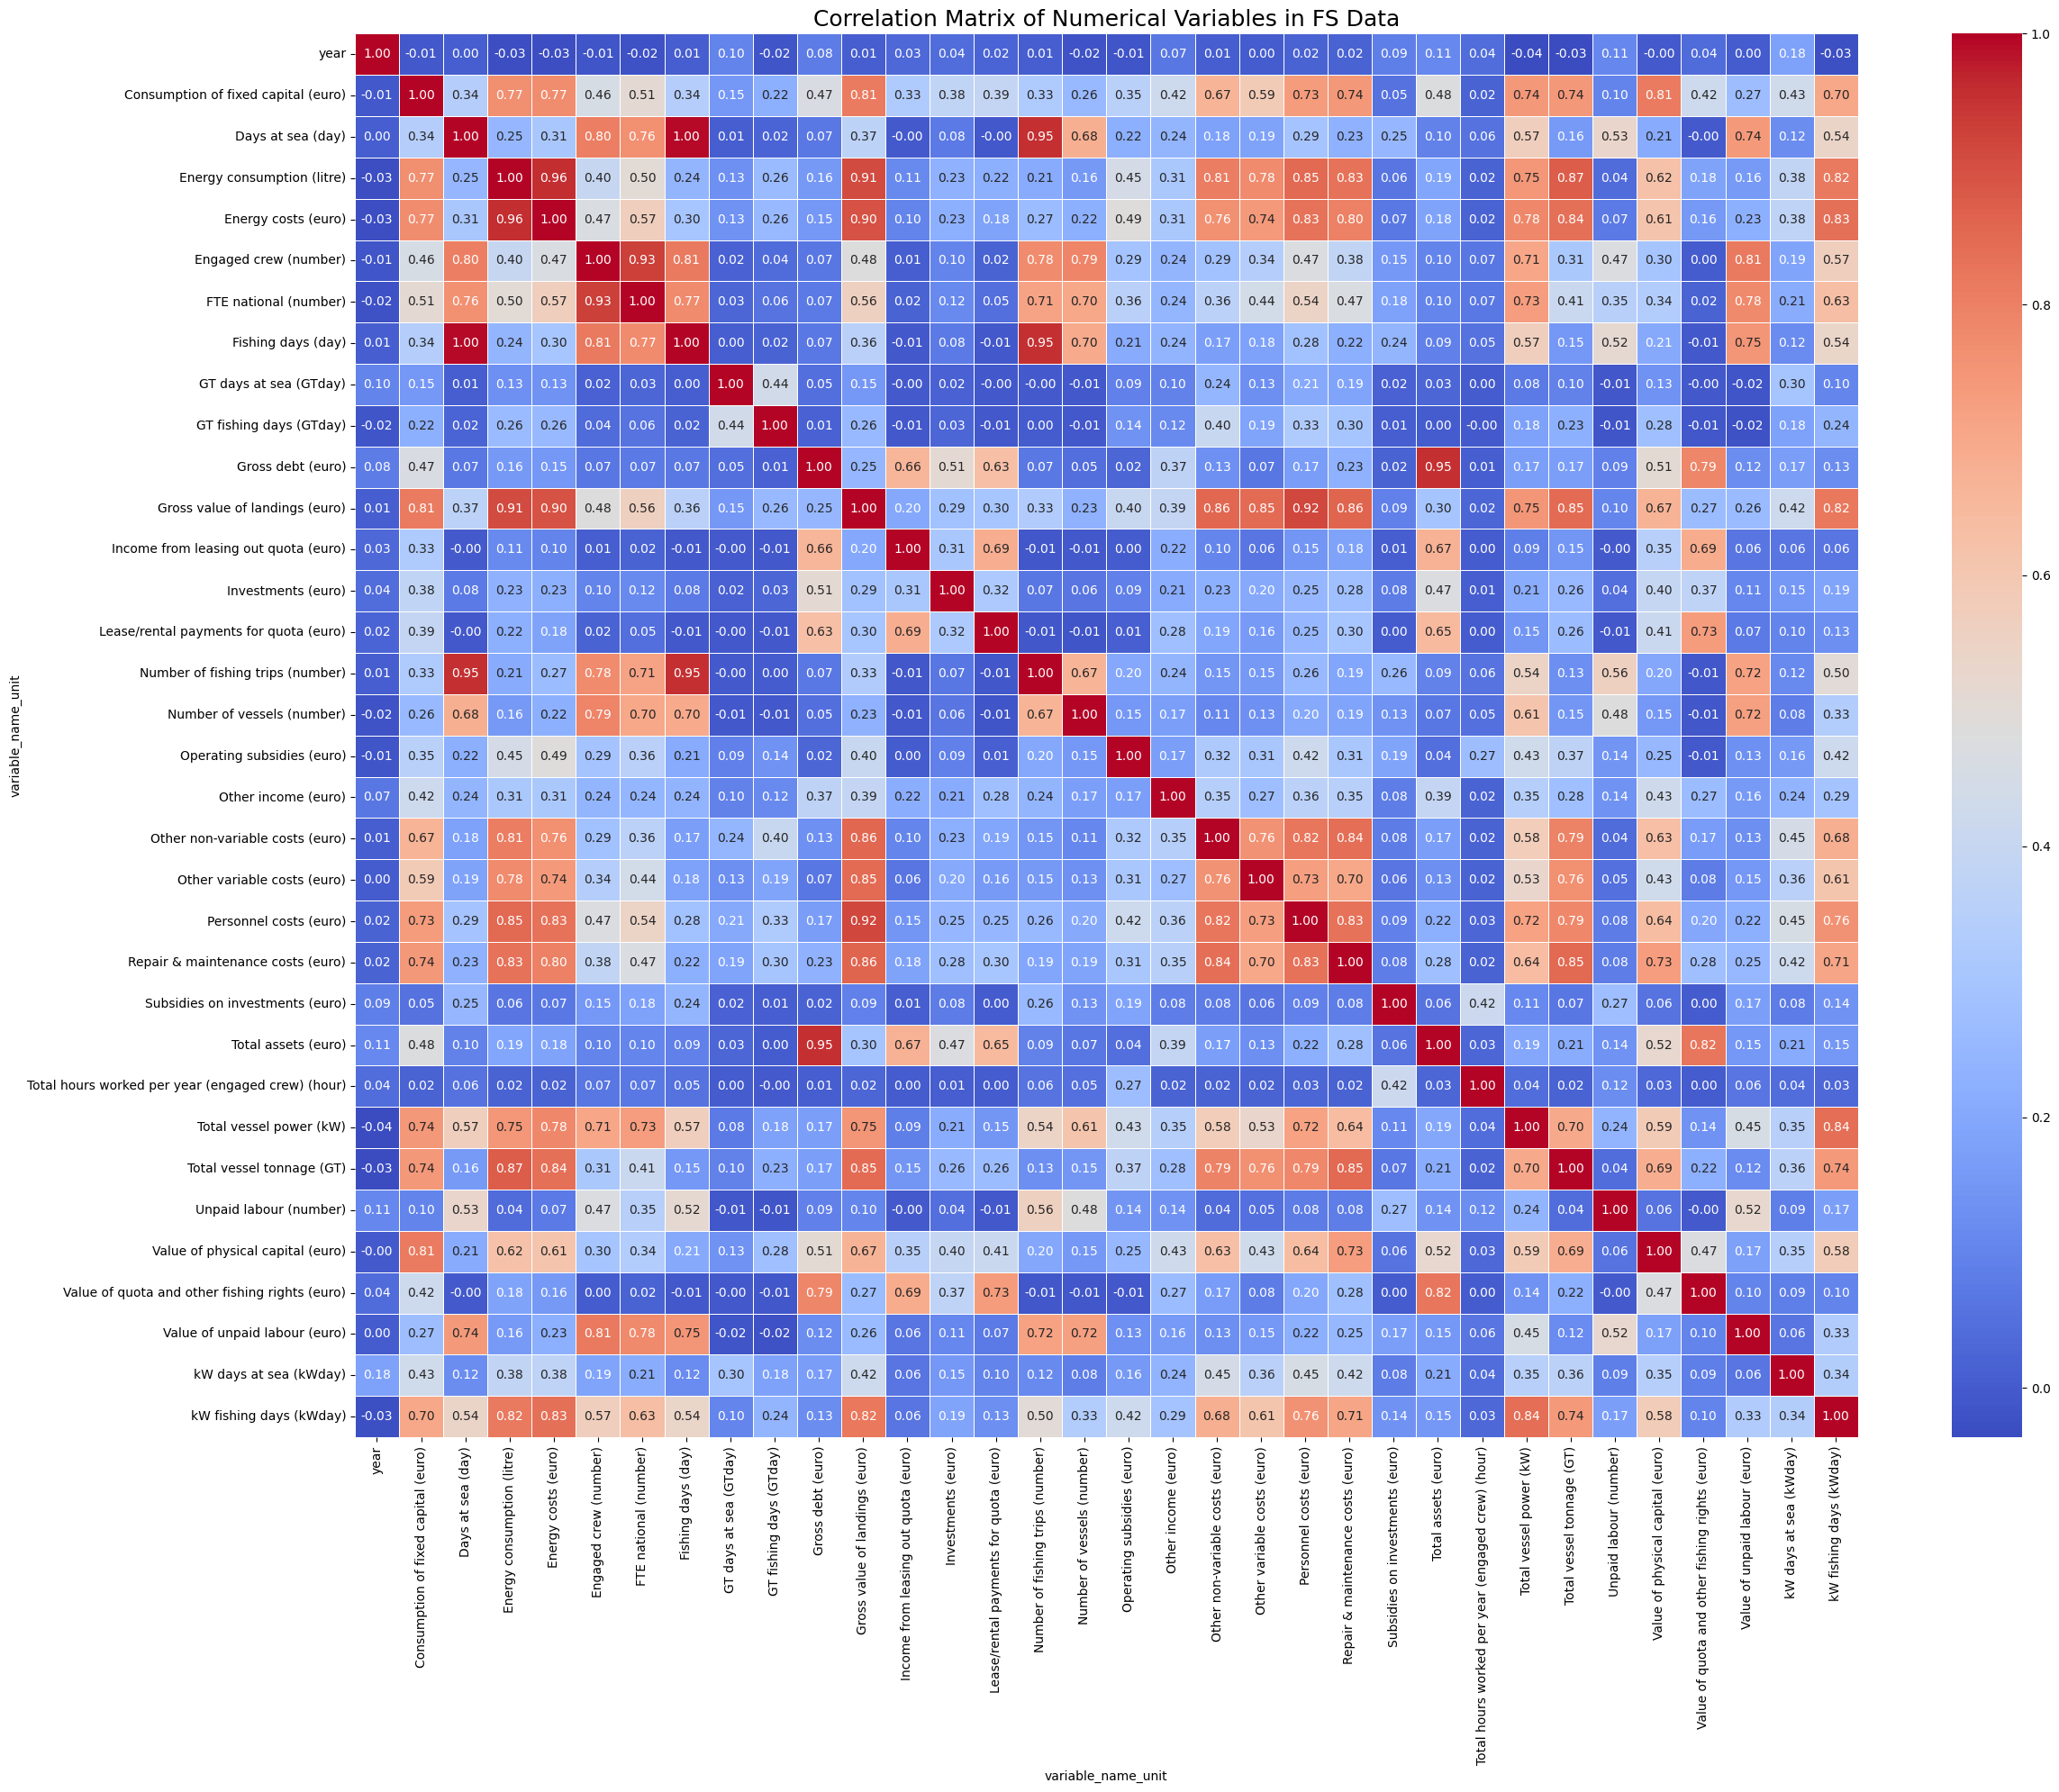

In [ ]:
# Calculate the correlation matrix
df_corr = var_num.corr()

# Set up the matplotlib figure and axes
fig, ax = plt.subplots(figsize=(25, 20)) # Adjust figure size as needed

# Create the heatmap
sns.heatmap(df_corr,
            xticklabels=df_corr.columns,
            yticklabels=df_corr.columns,
            cmap='coolwarm',
            annot=True, # Show the correlation values on the heatmap
            fmt=".2f", # Format the annotations to two decimal places
            linewidths=.5, # Add lines between cells
            ax=ax)

# Add a title to the plot
plt.title('Correlation Matrix of Numerical Variables in FS Data', fontsize=18)

# Rotate x-axis labels for better readability if needed
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show();

#### Consommation de carburant par catégorie de navires

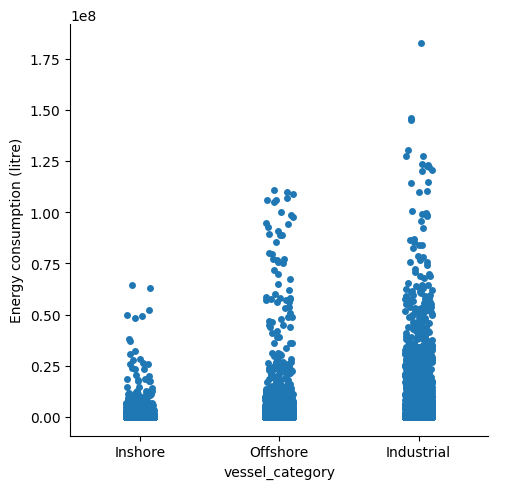

In [ ]:
sns.catplot(x = 'vessel_category', y ='Energy consumption (litre)',data =FS_wide )
plt.show();


#### Consommation de carburant par tonnage des navires

In [ ]:
g = sns.catplot(
    x='Total vessel tonnage (GT)',
    y='Energy consumption (litre)',
    data=FS_wide
)

# Supprimer ticks et labels de l’axe x
g.set(xticks=[], xlabel='')

plt.show();


KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x79bde26c4d60> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x79bde2686b60> (for post_execute):


KeyboardInterrupt: 

#### Distribution des navires en fonction de leur longueur

In [ ]:
#agrégation par année et longueur

length_year = FS_wide.groupby(
    ["year", "vessel_length"], as_index=False
)["Number of vessels (number)"].sum().rename(
    columns={"Number of vessels (number)": "nb_vessels"}
)

#moyenne annuelle par longueur de navire
length_mean = length_year.groupby(
    "vessel_length", as_index=False
)["nb_vessels"].mean()

#figure
plt.figure(figsize=(12, 6))

sns.barplot(
    data=length_mean,
    x="vessel_length",
    y="nb_vessels",
    order=length_mean.sort_values("nb_vessels", ascending=False)["vessel_length"]
)

plt.xlabel("Vessel length")
plt.ylabel("Average number of vessels per year")
plt.title("Average annual distribution of vessel length")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show();

#### Performance économque en fonction de la taille des flottes

NameError: name 'adjust_text' is not defined

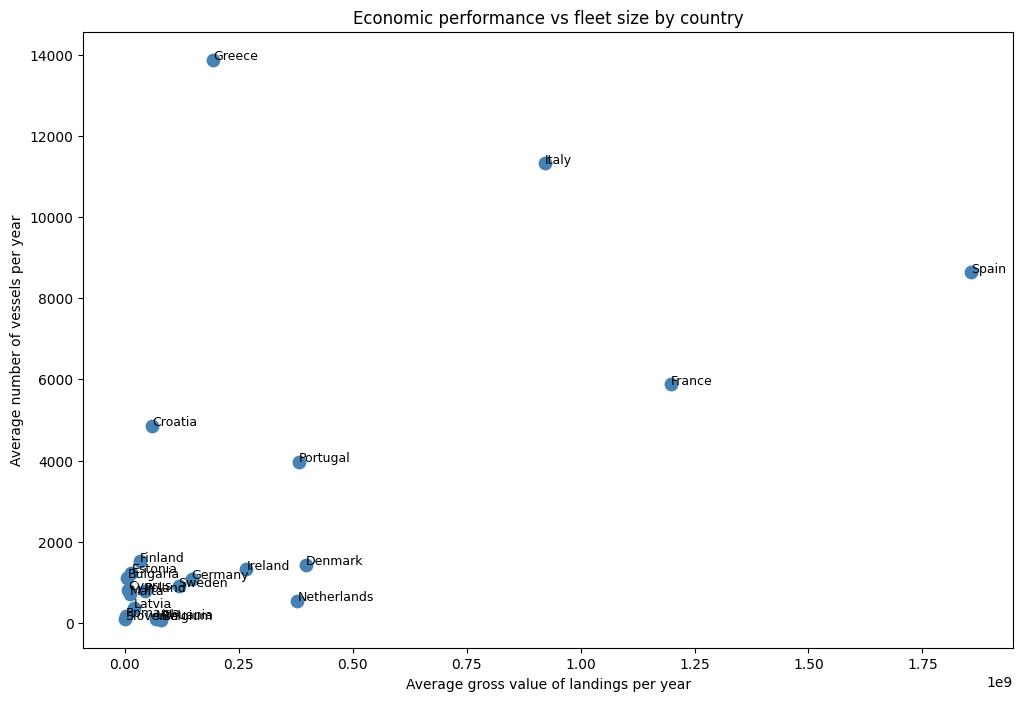

In [ ]:
ca_year_country = FS_wide.groupby(
    ["country_name", "year"], as_index=False
)["Gross value of landings (euro)"].sum()

# Nombre de bateaux par pays et année
boats_year_country = FS_wide.groupby(
    ["country_name", "year"], as_index=False
)["Number of vessels (number)"].sum().rename(columns={"Number of vessels (number)": "nb_vessels"})


ca_mean_country = ca_year_country.groupby("country_name", as_index=False)["Gross value of landings (euro)"].mean()
boats_mean_country = boats_year_country.groupby("country_name", as_index=False)["nb_vessels"].mean()

df_scatter = ca_mean_country.merge(boats_mean_country, on="country_name")

plt.figure(figsize=(12, 8))

# Scatter plot
plt.scatter(
    df_scatter["Gross value of landings (euro)"],
    df_scatter["nb_vessels"],
    color='steelblue',
    s=80
)

plt.xlabel("Average gross value of landings per year")
plt.ylabel("Average number of vessels per year")
plt.title("Economic performance vs fleet size by country")


# Créer les textes pour tous les pays
texts = []
for i, row in df_scatter.iterrows():
    texts.append(
        plt.text(
            row["Gross value of landings (euro)"],
            row["nb_vessels"],
            row["country_name"],
            fontsize=9
        )
    )

# Ajuster automatiquement pour éviter chevauchement
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))

plt.tight_layout()
plt.show();

#### Table de contingence techniques de pêche et catégorie de navires

In [ ]:
counts = FS_wide.groupby(
    ["year", "vessel_category", "fleet_category"], as_index=False
)["Number of vessels (number)"].sum().rename(columns={"Number of vessels (number)": "nb_boats"})


mean_per_comb = counts.groupby(
    ["vessel_category", "fleet_category"], as_index=False
)["nb_boats"].mean()


contingency_table_mean = mean_per_comb.pivot(
    index="vessel_category",
    columns="fleet_category",
    values="nb_boats"
)

print(contingency_table_mean)

# Ordre souhaité des vessel categories
order = ["Industrial", "Offshore","Inshore"]

# Réorganisation des lignes
contingency_table_mean = contingency_table_mean.reindex(order)

print("\n")

plt.figure(figsize=(10, 6))
sns.heatmap(contingency_table_mean, annot=True, fmt=".1f", cmap="Blues")
plt.ylabel("Vessel category")
plt.xlabel("Fleet category")
plt.title("Average number of vessels per year by Vessel x Fleet category")
plt.show();

### Landings

#### Poids des débarquements par espèce

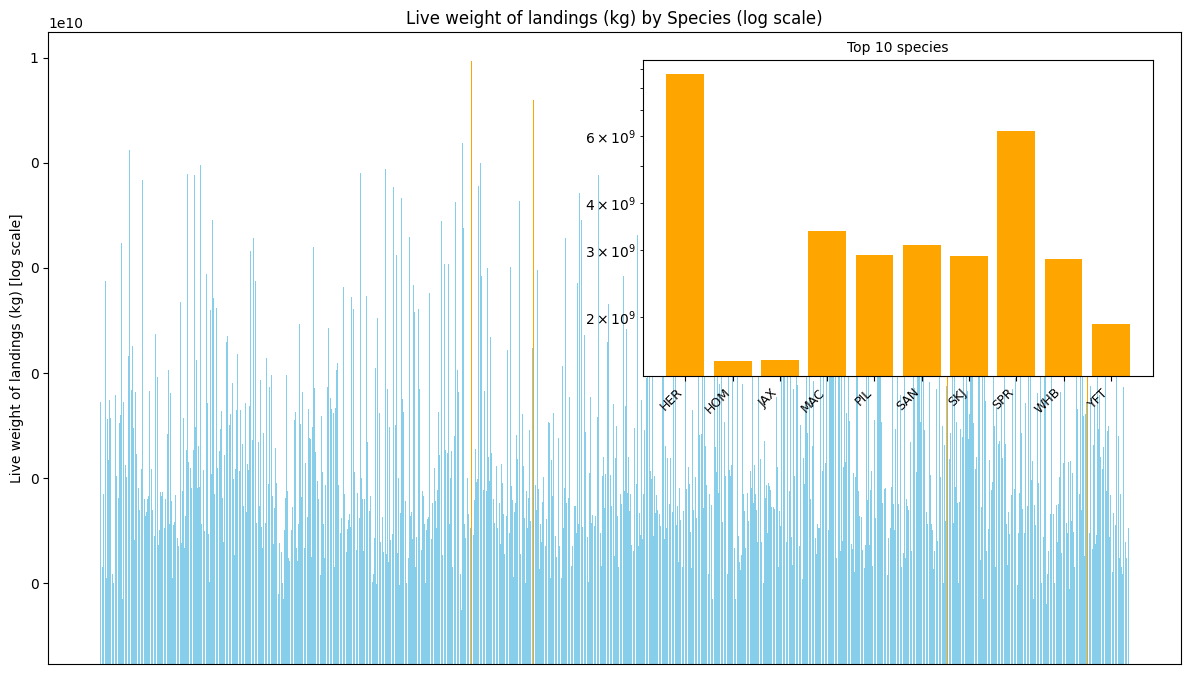

In [ ]:

# Agrégation par espèce
Landings_group = Landings_wide.groupby("species_code", as_index=False)["Live weight of landings (kg)"].sum()

# Top 10 espèces
top10 = Landings_group.nlargest(10, "Live weight of landings (kg)")["species_code"].tolist()

# --- Graphique principal ---
plt.figure(figsize=(15, 8))

# Couleurs : top10 en orange, le reste en bleu
colors = ['orange' if s in top10 else 'skyblue' for s in Landings_group["species_code"]]

bars = plt.bar(Landings_group["species_code"], Landings_group["Live weight of landings (kg)"], color=colors)

ax = plt.gca()
ax.set_yscale('log')           # axe log
ax.set_xticks([])              # pas de noms sur X
ax.yaxis.set_major_formatter(mtick.ScalarFormatter())
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))  # notation scientifique

plt.ylabel("Live weight of landings (kg) [log scale]")
plt.title("Live weight of landings (kg) by Species (log scale)")

# --- Inset pour top 10 ---
axins = inset_axes(ax, width="45%", height="50%", loc='upper right', borderpad=2)

# Barplot top 10
top10_df = Landings_group[Landings_group["species_code"].isin(top10)]
axins.bar(top10_df["species_code"], top10_df["Live weight of landings (kg)"], color='orange')

axins.set_yscale('log')
axins.yaxis.set_major_formatter(mtick.ScalarFormatter())
axins.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

# Labels X pour top 10
axins.set_xticks(range(len(top10_df)))
axins.set_xticklabels(top10_df["species_code"], rotation=45, ha='right', fontsize=9)
axins.set_title("Top 10 species", fontsize=10)

# Ajustement des marges
plt.subplots_adjust(right=0.88, top=0.9)

plt.show();

#### Valeur moyenne des débarquements par kg par espèce

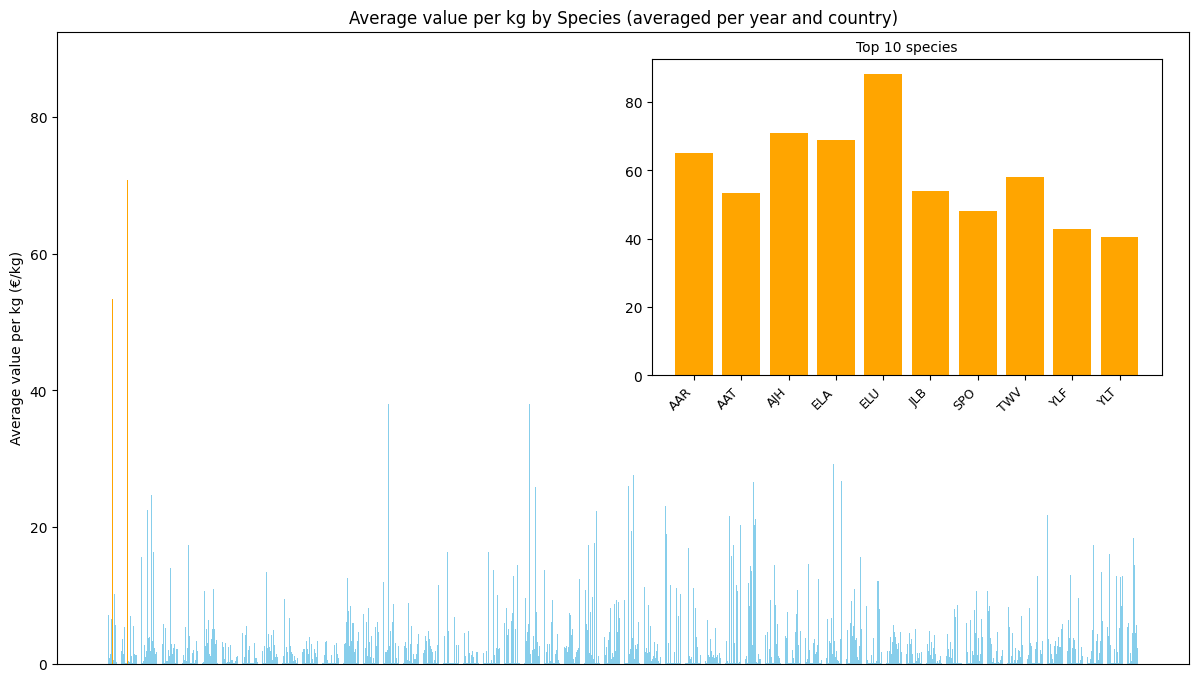

In [ ]:
# Calculer la valeur par kg pour chaque ligne
Landings_wide["value_per_kg"] = Landings_wide["Value of landings (euro)"] / Landings_wide["Live weight of landings (kg)"]

# Moyenne par année, pays et espèce
Landings_grouped = Landings_wide.groupby(
    ["year", "country_name", "species_code"], as_index=False
)["value_per_kg"].mean()

# Moyenne par espèce sur tous les pays et années
Landings_mean = Landings_grouped.groupby("species_code", as_index=False)["value_per_kg"].mean()

# Filtrer les NaN, inf et valeurs <= 0
Landings_mean_clean = Landings_mean.dropna(subset=["value_per_kg"]).copy()
Landings_mean_clean = Landings_mean_clean[
    Landings_mean_clean["value_per_kg"].replace([float('inf'), -float('inf')], pd.NA).notna()
]
Landings_mean_clean = Landings_mean_clean[Landings_mean_clean["value_per_kg"] > 0]

# Top 10 espèces selon la valeur moyenne
top10 = Landings_mean_clean.nlargest(10, "value_per_kg")["species_code"].tolist()

# --- Graphique principal ---
plt.figure(figsize=(15, 8))

# Couleurs : top10 en orange, le reste en bleu
colors = ['orange' if s in top10 else 'skyblue' for s in Landings_mean_clean["species_code"]]

bars = plt.bar(Landings_mean_clean["species_code"], Landings_mean_clean["value_per_kg"], color=colors)

ax = plt.gca()
ax.set_xticks([])  # pas de noms sur X
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))  # séparateurs de milliers

plt.ylabel("Average value per kg (€/kg)")
plt.title("Average value per kg by Species (averaged per year and country)")

# --- Inset pour top 10 ---
axins = inset_axes(ax, width="45%", height="50%", loc='upper right', borderpad=2)

top10_df = Landings_mean_clean[Landings_mean_clean["species_code"].isin(top10)]
axins.bar(top10_df["species_code"], top10_df["value_per_kg"], color='orange')

axins.set_yscale('linear')  # linéaire pour l'inset
axins.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

# Labels X pour top 10
axins.set_xticks(range(len(top10_df)))
axins.set_xticklabels(top10_df["species_code"], rotation=45, ha='right', fontsize=9)
axins.set_title("Top 10 species", fontsize=10)

# Ajustement des marges
plt.subplots_adjust(right=0.88, top=0.9)

plt.show();

#### Poids des débarquements par sous-région marine

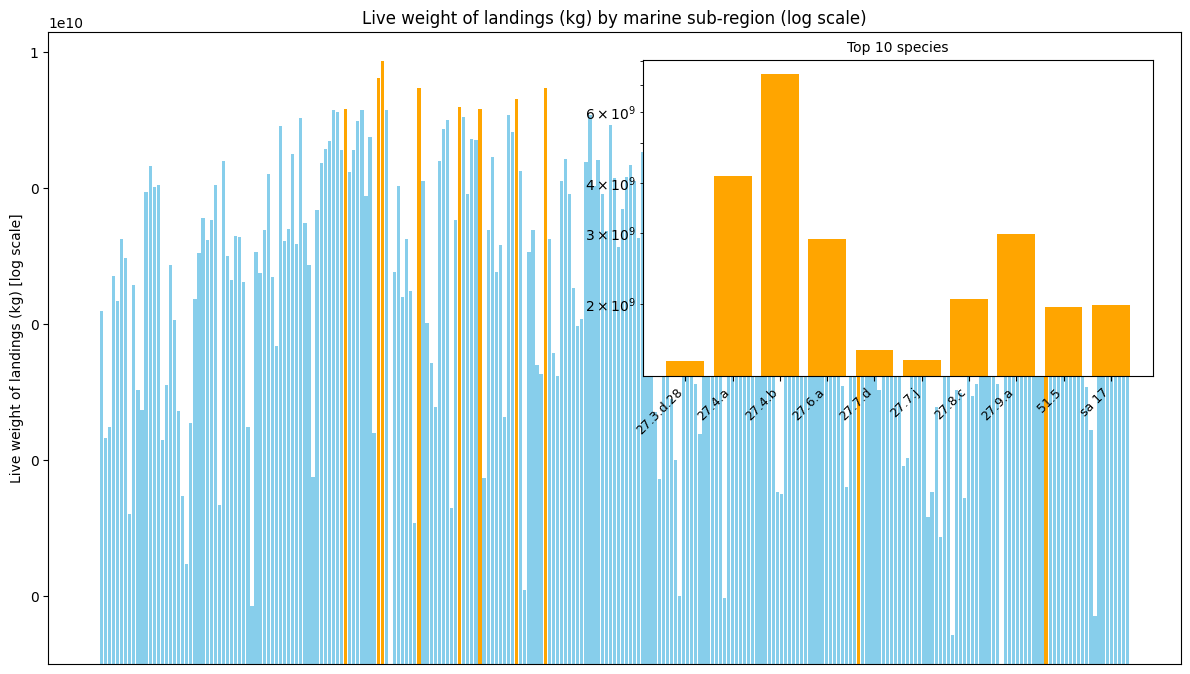

In [ ]:
# Agrégation par espèce
Landings_group = Landings_wide.groupby("sub_reg", as_index=False)["Live weight of landings (kg)"].sum()

# Top 10 espèces
top10 = Landings_group.nlargest(10, "Live weight of landings (kg)")["sub_reg"].tolist()

# --- Graphique principal ---
plt.figure(figsize=(15, 8))

# Couleurs : top10 en orange, le reste en bleu
colors = ['orange' if s in top10 else 'skyblue' for s in Landings_group["sub_reg"]]

bars = plt.bar(Landings_group["sub_reg"], Landings_group["Live weight of landings (kg)"], color=colors)

ax = plt.gca()
ax.set_yscale('log')           # axe log
ax.set_xticks([])              # pas de noms sur X
ax.yaxis.set_major_formatter(mtick.ScalarFormatter())
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))  # notation scientifique

plt.ylabel("Live weight of landings (kg) [log scale]")
plt.title("Live weight of landings (kg) by marine sub-region (log scale)")

# --- Inset pour top 10 ---
axins = inset_axes(ax, width="45%", height="50%", loc='upper right', borderpad=2)

# Barplot top 10
top10_df = Landings_group[Landings_group["sub_reg"].isin(top10)]
axins.bar(top10_df["sub_reg"], top10_df["Live weight of landings (kg)"], color='orange')

axins.set_yscale('log')
axins.yaxis.set_major_formatter(mtick.ScalarFormatter())
axins.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

# Labels X pour top 10
axins.set_xticks(range(len(top10_df)))
axins.set_xticklabels(top10_df["sub_reg"], rotation=45, ha='right', fontsize=9)
axins.set_title("Top 10 zones", fontsize=10)

# Ajustement des marges
plt.subplots_adjust(right=0.88, top=0.9)

plt.show();

## Exportation des données

### Fichiers de données

In [ ]:
FS_wide = FS_wide[['year', 'country_name', 'supra_reg',  'fleet_category', 'vessel_category',
       'fs_name','Consumption of fixed capital (euro)', 'Days at sea (day)',
       'Energy consumption (litre)', 'Energy costs (euro)',
       'Engaged crew (number)', 'FTE national (number)', 'Fishing days (day)',
       'GT days at sea (GTday)', 'GT fishing days (GTday)',
       'Gross debt (euro)', 'Gross value of landings (euro)',
       'Income from leasing out quota (euro)', 'Investments (euro)',
       'Lease/rental payments for quota (euro)',
       'Number of fishing trips (number)', 'Number of vessels (number)',
       'Operating subsidies (euro)', 'Other income (euro)',
       'Other non-variable costs (euro)', 'Other variable costs (euro)',
       'Personnel costs (euro)', 'Repair & maintenance costs (euro)',
       'Subsidies on investments (euro)', 'Total assets (euro)',
       'Total hours worked per year (engaged crew) (hour)',
       'Total vessel power (kW)', 'Total vessel tonnage (GT)',
       'Unpaid labour (number)', 'Value of physical capital (euro)',
       'Value of quota and other fishing rights (euro)',
       'Value of unpaid labour (euro)', 'kW days at sea (kWday)',
       'kW fishing days (kWday)']]

#FS_wide.to_csv('FS_wide.csv', index= False, sep=';', decimal=',')

In [ ]:
Landings_wide=Landings_wide[['year', 'country_name', 'supra_reg', 'sub_reg', 'fleet_category',
            'vessel_category',  'fs_name','species_code',
           'Live weight of landings (kg)', 'Value of landings (euro)']]

#Landings_wide.to_csv('Landings_wide.csv', index= False, sep=';', decimal=',')

### Tables de dimension

A partir du dataframe FS_wide, récupération des fichiers pour les futures tables de dimensions de Power BI.

In [ ]:
fleet_category = FS_wide["fleet_category"].drop_duplicates()
#fleet_category.to_csv('fleet_category.csv', index= False, sep=';', decimal=',')
vessel_category = FS_wide["vessel_category"].drop_duplicates()
#vessel_category.to_csv('vessel_category.csv', index= False, sep=';', decimal=',')
#species_category = Landings_wide[["species_name", "species_code"]].drop_duplicates()
#species_category.to_csv('species_category.csv', index= False, sep=';', decimal=',')


In [ ]:
species_category_id = '1xi9jVrUIeIhEaiFDshVlJtG3CUphdILc'
url_species_category= f'https://drive.google.com/uc?id={species_category_id}'

gdown.download(url_species_category, 'species_category.csv', quiet=True)

species_category = pd.read_csv('species_category.csv', sep=';', decimal= ',')
display(species_category['category'].value_counts())

,count
category,
Other Species,6715
Other fish,1472
Bivalve molluscs (shellfish),1057
Crustaceans,1000
Other demersal fish,862
Cartilaginous fish,804
Bluefish,320
Cephalopods,277
Flatfish,267
